# MCS-201 Hardware Acceleration
**Artificial Intelligence and System Engineering · Prince of Songkla University, Phuket Campus**

---

# Lab 2 — Device Query, Achieved Bandwidth and Your Own Roofline
### การอ่านสเปก GPU การวัดแบนด์วิดท์จริง และการสร้าง roofline ของเครื่องตนเอง

| | |
|---|---|
| **สัปดาห์** | 3 |
| **วันปฏิบัติการ** | จันทร์ 31 ส.ค. 2569 |
| **กำหนดส่ง** | จันทร์ 31 ส.ค. 2569 **ภายใน 13.00 น.** (วันเดียวกับคาบปฏิบัติการ) |
| **น้ำหนัก** | อยู่ในหมวด Lab ซึ่งคิดเป็น 15% ของคะแนนรายวิชา (ทุกแลปถ่วงน้ำหนักเท่ากัน) |
| **ช่องทางส่ง** | LMS — lms.psu.ac.th |
| **ไฟล์ที่ต้องส่ง** | `Lab2_<รหัสนักศึกษา>.ipynb` (ไฟล์เดียว) |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ · thitinan.kl@phuket.psu.ac.th · ห้อง 6714 |

> **การส่งงาน** อัปโหลดผ่าน LMS ภายใน 13.00 น. ของวันปฏิบัติการ
>
> **การส่งช้า** นับจาก 13.00 น. ของวันปฏิบัติการ หักวันละ 10% ของคะแนนแลปนี้
> และไม่รับหลังพ้นกำหนด 7 วัน (ยกเว้นกรณีมีเหตุจำเป็นและได้รับอนุมัติล่วงหน้า)
>
> **ห้ามล้าง output ก่อนส่ง** ผู้ตรวจต้องเห็นผลลัพธ์ที่รันจริง

> **กติกาสำคัญ** ส่วนที่ 4 ต้องกรอกช่อง "ทำนาย" ให้ครบ **ก่อน** รันโค้ดวัดผล
> การทำนายผิดแต่ให้เหตุผลดี ได้คะแนนสูงกว่าการทำนายถูกโดยไม่มีเหตุผล

## 1. วัตถุประสงค์ (Objectives)

1. อ่านคุณสมบัติของ GPU จากโปรแกรมและตีความความหมายของแต่ละค่าได้ — *CLO1*
2. วัดแบนด์วิดท์หน่วยความจำที่ทำได้จริง และเปรียบเทียบกับค่าที่ผู้ผลิตระบุ — *CLO1, CLO3*
3. คำนวณ ridge point ของ GPU ที่ใช้ และสร้างกราฟ roofline ของตนเอง — *CLO1*
4. ฝึกนิสัยการทำนายผลก่อนวัดจริง ซึ่งเป็นทักษะหลักของงานด้านสมรรถนะ — *CLO3*

## 2. สิ่งที่ต้องเตรียม (Prerequisites)

- ทำ **Lab 0** เสร็จแล้ว (จะนำค่า TFLOPS ของ GPU มาใช้เทียบ)
- ค่า **peak memory bandwidth ตามสเปก** ของการ์ดที่ได้รับ ใช้ตารางนี้ได้

| การ์ด | peak bandwidth (สเปก) |
|---|---|
| Tesla T4 | 320 GB/s |
| L4 | 300 GB/s |
| A100 40GB | 1,555 GB/s |
| A100 80GB | 2,039 GB/s |

> **หมายเหตุ** ตารางนี้ให้เฉพาะแบนด์วิดท์ เพราะจำเป็นต้องใช้เทียบกับค่าที่วัดได้ในส่วนที่ 2
> ส่วน **peak FP32 ท่านต้องคำนวณเอง** ในส่วนที่ 3 จากจำนวน lane และ boost clock

---
## 3. ขั้นตอนการปฏิบัติ

### ส่วนที่ 1 — อ่านคุณสมบัติของอุปกรณ์

In [1]:
import torch
assert torch.cuda.is_available(), "เปลี่ยน Runtime เป็น GPU ก่อน"

p = torch.cuda.get_device_properties(0)
info = {
    "name"                    : p.name,
    "compute capability"      : f"{p.major}.{p.minor}",
    "SM count"                : p.multi_processor_count,
    "global memory (GB)"      : round(p.total_memory / 1024**3, 2),
    "shared mem per SM (KB)"  : p.shared_memory_per_multiprocessor // 1024,
    "regs per SM"             : p.regs_per_multiprocessor,
    "max threads per SM"      : p.max_threads_per_multi_processor,
    "warp size"               : p.warp_size,
}
for k, v in info.items():
    print(f"{k:26s}: {v}")

name                      : Tesla T4
compute capability        : 7.5
SM count                  : 40
global memory (GB)        : 14.56
shared mem per SM (KB)    : 64
regs per SM               : 65536
max threads per SM        : 1024
warp size                 : 32


### ตารางที่ 1 — คุณสมบัติอุปกรณ์

| รายการ | ค่าที่อ่านได้ | ความหมาย / เหตุผลที่ค่านี้สำคัญ |
|---|---|---|
| ชื่อ GPU | Tesla T4 | |
| Compute capability | 7.5 | |
| จำนวน SM | 40 | |
| Global memory (GB) | 14.56 | |
| Shared memory ต่อ SM (KB) | 64 | |
| Registers ต่อ SM | 65536 | |
| Max threads ต่อ SM | 1024 | |
| Warp size | 32 | |

**1.2 — สองค่าที่ `get_device_properties` ไม่ได้บอก**

การคำนวณ peak FP32 ในส่วนที่ 3 ต้องใช้ **จำนวน FP32 lanes ต่อ SM** และ **boost clock**
ซึ่งทั้งสองค่า **ไม่มี** อยู่ใน `get_device_properties`

| ค่า | หาได้จาก |
|---|---|
| FP32 lanes ต่อ SM | สเปกของผู้ผลิต หรือ CUDA C Programming Guide (ขึ้นกับ compute capability) |
| Boost clock | สเปกของผู้ผลิต |

In [2]:
import subprocess

# ตารางนี้มาจาก _ConvertSMVer2Cores() ใน helper_cuda.h ของ CUDA Toolkit
# จำนวน FP32 lane ต่อ SM ถูกกำหนดโดยสถาปัตยกรรม ไม่ใช่โดยรุ่นการ์ด
SM_TO_LANES = {
    (6, 0): 64,    # Pascal GP100
    (6, 1): 128,   # Pascal GP10x   (GTX 10xx)
    (7, 0): 64,    # Volta   V100
    (7, 5): 64,    # Turing  T4, RTX 20xx
    (8, 0): 64,    # Ampere  A100
    (8, 6): 128,   # Ampere  GA10x  (RTX 30xx, A40)
    (8, 9): 128,   # Ada     L4, RTX 40xx
    (9, 0): 128,   # Hopper  H100
    (10, 0): 128,  # Blackwell
    (12, 0): 128,  # Blackwell consumer
}

cc = (p.major, p.minor)
lanes_per_sm = SM_TO_LANES.get(cc)
print(f"compute capability {cc[0]}.{cc[1]}  ->  lanes/SM = {lanes_per_sm}")
if lanes_per_sm is None:
    print("  !! ไม่มีในตาราง — ให้เปิดสเปกของผู้ผลิตแล้วกรอกเองในส่วนที่ 3")


# คืน (ค่าเป็น Hz, ชื่อแหล่งที่มา) หรือ (None, None) ถ้าอ่านไม่ได้
def read_boost_clock_hz():
    try:                                   # 1) nvidia-smi (น่าเชื่อถือที่สุด)
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=clocks.max.sm",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, timeout=15)
        mhz = float(out.stdout.strip().splitlines()[0])
        return mhz * 1e6, "nvidia-smi clocks.max.sm"
    except Exception:
        pass
    try:                                   # 2) PyTorch (บางเวอร์ชันเท่านั้น)
        return p.clock_rate * 1e3, "torch clock_rate (kHz)"
    except Exception:
        return None, None


boost_hz, src = read_boost_clock_hz()
if boost_hz:
    print(f"boost clock       : {boost_hz/1e9:.3f} GHz   (แหล่ง: {src})")
else:
    print("boost clock       : อ่านอัตโนมัติไม่ได้ — ให้กรอกเองจากสเปกผู้ผลิต")

print()
print("ค่าข้างบนเป็นเพียงตัวช่วยตรวจสอบ")

compute capability 7.5  ->  lanes/SM = 64
boost clock       : 1.590 GHz   (แหล่ง: nvidia-smi clocks.max.sm)

ค่าข้างบนเป็นเพียงตัวช่วยตรวจสอบ


### ตารางที่ 2 — ค่าที่ใช้คำนวณ peak

| ค่า | ค่าที่ใช้ |
|---|---|
| จำนวน SM | 40 |
| FP32 lanes ต่อ SM | 64 |
| Boost clock (GHz) | 1.590 |
| Peak BW ตามสเปก (GB/s) | 320 |
| Peak FP16 Tensor ตามสเปก (TFLOPS) | 65 |

**ทำไมต้องมีแถวสุดท้าย** peak ของ Tensor Core **คำนวณจาก lanes × 2 × clock ไม่ได้**
เพราะ Tensor Core เป็นวงจรคนละชุดกับเลน FP32 ค่านี้จึงต้องอ่านจากสเปกของผู้ผลิตอย่างเดียว
(เช่น Tesla T4 = 65 TFLOPS · L4 = 121 · A100 80GB = 312) และจะได้ใช้ในแถว FP16 ของส่วนที่ 4

**หมายเหตุ** `nvidia-smi` รายงาน clock **สูงสุดที่อนุญาต** ซึ่งอาจสูงกว่า clock ที่ทำได้จริง
ต่อเนื่อง เพราะการ์ดจะลดความถี่ลงเมื่อร้อนหรือชนเพดานพลังงาน (thermal / power throttling)
ค่า peak ที่คำนวณได้จึงเป็น **เพดานทางทฤษฎี** ไม่ใช่ค่าที่จะวัดได้จริง

---
### ส่วนที่ 2 — วัดแบนด์วิดท์ที่ทำได้จริง

**2.1 สูตรที่ต้องใช้**

```
แบนด์วิดท์ (GB/s)  =  ไบต์ที่เคลื่อนย้ายทั้งหมด  ÷  เวลาที่ใช้ (วินาที)  ÷  1e9
```

*ไบต์ที่เคลื่อนย้าย* — `b = a.clone()` **อ่าน a ทั้งก้อน 1 รอบ และเขียน b ทั้งก้อน 1 รอบ**
จึงเป็น **2 × ขนาดของ a** ในโค้ดเขียนได้เป็น `2 * a.nbytes`
(`.nbytes` คือจำนวนไบต์ทั้งหมดของเทนเซอร์ = จำนวนสมาชิก × ขนาดชนิดข้อมูล)

*เวลา* — ตัวแปร `dt` ในโค้ดคำนวณไว้ให้แล้ว เป็น **เวลาต่อหนึ่งรอบ** หน่วยวินาที
(จับเวลา `reps` รอบแล้วหารด้วย `reps` เพื่อลดผลของสัญญาณรบกวน)

*ทำไมหารด้วย `1e9` ไม่ใช่ `2**30`* — ผู้ผลิตรายงาน GB/s แบบ **ฐานสิบ** (1 GB = 10⁹ ไบต์)
ถ้าใช้ฐานสองจะได้ตัวเลขต่ำกว่าราว 7% แล้วเอาไปเทียบกับสเปกไม่ได้

> **จุดที่พลาดกันมากที่สุดคือเลข 2** ถ้าลืมคูณ จะได้แบนด์วิดท์เพียงครึ่งเดียว
> แล้วสรุปผิดว่าเครื่องทำได้แค่ ~35% ของสเปก

In [3]:
import time

def measure_bandwidth(n_bytes=1024**3, reps=20):
    n = n_bytes // 4
    a = torch.empty(n, dtype=torch.float32, device="cuda")

    b = a.clone(); torch.cuda.synchronize()          # warm-up
    t0 = time.perf_counter()
    for _ in range(reps):
        b = a.clone()
    torch.cuda.synchronize()
    dt = (time.perf_counter() - t0) / reps

    # TODO: คำนวณแบนด์วิดท์เป็น GB/s (อย่าลืมคูณ 2)
    bw = (2 * a.nbytes) / dt / 1e9
    assert bw is not None, "ยังไม่ได้คำนวณ bw"
    return bw, dt

bw, dt = measure_bandwidth()
print(f"achieved bandwidth : {bw:.0f} GB/s   ({dt*1e3:.2f} ms ต่อรอบ)")

SPEC_BW = 320      # TODO: ใส่ค่า peak bandwidth จากตารางในหัวข้อที่ 2 (GB/s)
assert SPEC_BW, "ยังไม่ได้ใส่ SPEC_BW"
print(f"เทียบกับสเปก        : {bw / SPEC_BW * 100:.0f} %")

achieved bandwidth : 241 GB/s   (8.91 ms ต่อรอบ)
เทียบกับสเปก        : 75 %


> **ค่าที่ควรได้** โดยทั่วไปแบนด์วิดท์ที่วัดได้จะอยู่ที่ประมาณ **70–85%** ของค่าที่ผู้ผลิตระบุ
> ถือเป็นเรื่องปกติ หากได้ต่ำกว่า 50% ให้ตรวจว่าลืม `synchronize()` หรือขนาดข้อมูลเล็กเกินไป

---
### ส่วนที่ 3 — คำนวณ roofline ของเครื่องท่าน

**3.1** `peak FP32 = (จำนวน FP32 lanes) × 2 × (boost clock)` — เลข 2 มาจากคำสั่ง FMA ที่นับเป็น 2 FLOP
ส่วน `peak FP16 Tensor` **คำนวณแบบนี้ไม่ได้** ให้ใช้ค่าจากสเปกในตารางที่ 2 ตรง ๆ
**3.2** `ridge point = peak FLOPS ÷ แบนด์วิดท์ที่วัดได้จริง` (ไม่ใช่ค่าจากสเปก)
ต้องคำนวณ **สองค่า**: ridge ของ FP32 และ ridge ของ FP16 Tensor
**3.3** วาดกราฟ roofline: แกน x เป็น arithmetic intensity (log) แกน y เป็น attainable TFLOPS (log)
พร้อมวางจุดของ kernel ทั้ง 4 รายการลงบนกราฟ

In [4]:
# TODO: กรอกจากตารางที่ 2
FP32_LANES  = 40 * 64     # จำนวน SM x lanes ต่อ SM
BOOST_CLOCK = 1.590e9    # หน่วย Hz (ไม่ใช่ MHz)
PEAK_FP16_TF = 65   # TFLOPS จากสเปก (คำนวณเองไม่ได้)  เช่น T4 = 65

assert FP32_LANES and BOOST_CLOCK and PEAK_FP16_TF, "ยังไม่ได้กรอกตัวเลขของการ์ดที่ใช้"

peak_flops = FP32_LANES * 2 * BOOST_CLOCK      # FP32 คำนวณได้จาก lanes x 2 x clock
peak_fp16  = PEAK_FP16_TF * 1e12               # Tensor Core อ่านจากสเปกอย่างเดียว

ridge      = peak_flops / (bw * 1e9)           # ridge ของ FP32
ridge_fp16 = peak_fp16  / (bw * 1e9)           # ridge ของ FP16 Tensor

print(f"measured BW      : {bw:.0f} GB/s")
print(f"peak FP32        : {peak_flops/1e12:.2f} TFLOPS   ridge = {ridge:.1f} FLOP/byte")
print(f"peak FP16 Tensor : {peak_fp16/1e12:.2f} TFLOPS   ridge = {ridge_fp16:.1f} FLOP/byte")

measured BW      : 241 GB/s
peak FP32        : 8.14 TFLOPS   ridge = 33.8 FLOP/byte
peak FP16 Tensor : 65.00 TFLOPS   ridge = 269.7 FLOP/byte


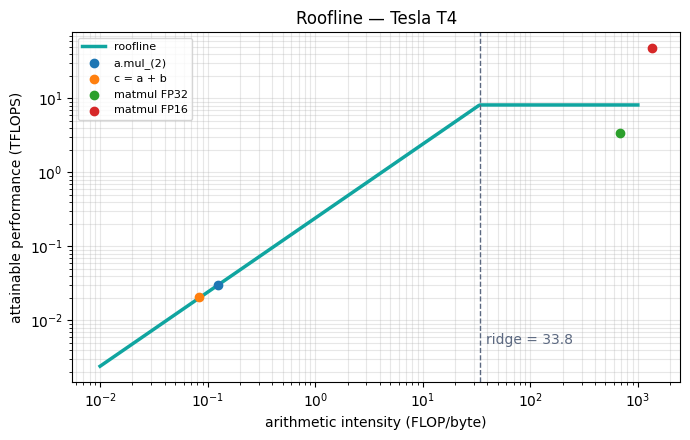

In [5]:
import numpy as np, matplotlib.pyplot as plt

# TODO: กรอกจุดของ kernel ทั้ง 4 รายการ หลังทำส่วนที่ 4 เสร็จแล้ว
#       รูปแบบ: (ชื่อ kernel, arithmetic intensity ที่คำนวณเอง, TFLOPS ที่วัดได้)
KERNEL_POINTS = [
    ("a.mul_(2)",   0.125, 0.030),
    ("c = a + b",   0.0833, 0.021),
    ("matmul FP32", 682.67, 3.426),
    ("matmul FP16", 1365.33, 47.495),
]


missing = [nm for nm, x, y in KERNEL_POINTS if x is None or y is None]
assert not missing, (
    "ยังไม่ได้กรอกค่าของ: " + ", ".join(missing) +
    "  --> ให้ทำส่วนที่ 4 ให้เสร็จก่อน แล้วย้อนกลับมากรอก KERNEL_POINTS")

ai = np.logspace(-2, 3, 400)
attainable = np.minimum(peak_flops, bw * 1e9 * ai) / 1e12

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(ai, attainable, lw=2.5, color="#10A5A0", label="roofline")
ax.axvline(ridge, ls="--", color="#5B6880", lw=1)
ax.text(ridge*1.15, attainable.min()*2, f"ridge = {ridge:.1f}", color="#5B6880")

for name, x, y in KERNEL_POINTS:
    ax.scatter([x], [y], zorder=5, label=name)

ax.set_xlabel("arithmetic intensity (FLOP/byte)")
ax.set_ylabel("attainable performance (TFLOPS)")
ax.set_title(f"Roofline — {info['name']}")
ax.grid(alpha=.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
### ส่วนที่ 4 — ทำนายก่อน แล้วจึงวัด

**สองคอลัมน์แรกให้ไว้แล้ว** (ที่มาอยู่ในข้อ 4.1) — กรอกสามช่องที่เหลือ
คือ **AI · ชนิด · ทำนายเวลา** ให้ครบ **ก่อน** รันเซลล์วัดผล

| ภาระงาน | FLOP ทั้งหมด | ไบต์ผ่าน DRAM | AI (คำนวณเอง) | ทำนาย: memory / compute-bound | ทำนายเวลา (ms) | เวลาที่วัดได้ (ms) |
|---|---|---|---|---|---|---|
| `a.mul_(2)` in-place, n = 2²⁶ | 6.71e7 | 5.37e8 (0.537 GB) | 0.125 | memory-bound | 2.23 | 2.239 |
| `c = a + b`, n = 2²⁶ | 6.71e7 | 8.05e8 (0.805 GB) | 0.0833 | memory-bound | 3.34 | 3.269 |
| matmul 4096 FP32 | 1.37e11 | 2.01e8 (0.201 GB) | 682.67 | compute-bound | 16.88 | 40.115 |
| matmul 4096 FP16 | 1.37e11 | 1.01e8 (0.101 GB) | 1365.33 | compute-bound | 2.11 | 2.894 |

**4.1 ที่มาของสองคอลัมน์ที่ให้ไว้ — และการคำนวณ AI**

```
AI  =  FLOP ทั้งหมด  ÷  ไบต์ที่วิ่งผ่าน DRAM ทั้งหมด
```

สองคอลัมน์แรกในตารางได้มาจากการนับตามโค้ดในเซลล์วัดผล ซึ่งใช้ `n = 2**26` = 67,108,864
และ `m = 4096`

*สูตรที่ใช้*
- **FLOP** — elementwise: 1 FLOP ต่อสมาชิก × n · matmul N×N: 2N³ (คูณ N³ + บวก N³)
- **ไบต์** = (จำนวนรอบที่อาร์เรย์ถูกอ่าน + เขียน) × (จำนวนสมาชิก) × (ขนาดชนิดข้อมูล)
  โดย float32 = 4 ไบต์ · **float16 = 2 ไบต์**

*ที่มาของแต่ละแถว*

| ภาระงาน | FLOP | ไบต์ |
|---|---|---|
| `a.mul_(2)` in-place | 1 × n = 6.71e7 | อ่าน 1 + เขียน 1 = **2 รอบ** → 2 × n × 4 = 5.37e8 |
| `c = a + b` | 1 × n = 6.71e7 | อ่าน a + อ่าน b + เขียน c = **3 รอบ** → 3 × n × 4 = 8.05e8 |
| matmul 4096 FP32 | 2m³ = 1.37e11 | A + B + C = **3m² สมาชิก** → 3m² × 4 = 2.01e8 |
| matmul 4096 FP16 | 2m³ = 1.37e11 | 3m² สมาชิก แต่ **× 2 ไบต์** → 3m² × 2 = 1.01e8 |

> **ข้อสมมติที่ต้องรู้** เรานับว่าข้อมูลแต่ละตัว **วิ่งผ่าน DRAM เพียงครั้งเดียว**
> ซึ่งเป็นกรณีดีที่สุด (สมมติว่า cache ทำงานสมบูรณ์แบบ) สำหรับ matmul ที่ cuBLAS ทำ tiling ให้
> สมมติฐานนี้ใกล้เคียงความจริง แต่ถ้าเขียน kernel เองแบบไม่ tile ไบต์จริงจะมากกว่านี้หลายเท่า
> นี่คือเหตุผลที่ roofline เรียกว่า "เพดาน" ไม่ใช่ "คำทำนาย" — เราจะทำ tiling เองในสัปดาห์ที่ 5

**สิ่งที่ต้องทำ** เอาสองคอลัมน์ที่ให้ไว้มาหารกัน ได้ AI ของทั้งสี่แถว
สังเกตด้วยว่า elementwise ตัว n ตัดกันหมด → AI ไม่ขึ้นกับขนาดข้อมูล
ส่วน matmul AI โตตาม m — ให้ดูว่าโตแบบไหน และทำไม FP16 จึงไม่เท่ากับ FP32

**4.2 ตัดสิน memory- หรือ compute-bound (คอลัมน์ที่ 2)**

เทียบ AI ที่คำนวณได้กับ **ridge point ของเครื่องท่านจากข้อ 3.1**
- AI **น้อยกว่า** ridge → memory-bound
- AI **มากกว่า** ridge → compute-bound

> แถว FP16 ให้เทียบกับ `ridge_fp16` (ของ Tensor Core) ไม่ใช่ `ridge` ของ FP32

**4.3 ทำนายเวลา (คอลัมน์ที่ 3)**
- memory-bound: `t = ไบต์ทั้งหมด ÷ แบนด์วิดท์ที่วัดได้จริง` (จากส่วนที่ 2)
- compute-bound: `t = FLOP ทั้งหมด ÷ peak FLOPS` (จากข้อ 3.1)
  — สามแถวแรกใช้ `peak_flops` (FP32) · **แถว FP16 ใช้ `peak_fp16`** ของ Tensor Core

**4.4 คอลัมน์สุดท้าย — เวลาที่วัดได้ (กรอกหลังรันเซลล์ถัดไป)**

รันเซลล์ถัดไป มันจะพิมพ์ออกมา 4 บรรทัด เรียงตรงกับ 4 แถวของตารางพอดี บรรทัดละ 2 ค่า:

```
a.mul_(2)          2.239 ms      0.030 TFLOPS
                   ^^^^^^^^      ^^^^^^^^^^^^
                   คอลัมน์สุดท้าย   ใช้เป็นพิกัด y ของกราฟ roofline (ข้อ 3.3)
```

- คัดลอกค่า **ms** ลงคอลัมน์ "เวลาที่วัดได้" ของตาราง
- เก็บค่า **TFLOPS** ไว้ด้วย เพราะต้องใช้เป็นพิกัด y ใน `KERNEL_POINTS` ของข้อ 3.3
  (พิกัด x คือ AI ที่คำนวณในข้อ 4.1)
- เมื่อกรอกครบแล้ว **ย้อนกลับไปรันเซลล์กราฟในข้อ 3.3 อีกครั้ง**

> **ห้ามแก้ช่องทำนายหลังเห็นผลจริง** ถ้าทำนายพลาด ให้ปล่อยไว้แล้วอธิบายสาเหตุ
> เกณฑ์ให้คะแนนส่วนนี้ดูที่คุณภาพของเหตุผล ไม่ใช่ความแม่นของตัวเลข

In [6]:
def timed(fn, reps=20):
    fn(); torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps

n = 2**26
a = torch.randn(n, device="cuda")
b = torch.randn(n, device="cuda")

t_scale = timed(lambda: a.mul_(2))      # in-place: อ่าน 4 B + เขียน 4 B = 8 B ต่อสมาชิก
t_add   = timed(lambda: a + b)          # อ่าน 4+4 B, เขียน 4 B = 12 B ต่อสมาชิก

m = 4096
A32 = torch.randn(m, m, device="cuda"); B32 = torch.randn(m, m, device="cuda")
A16 = A32.half();                        B16 = B32.half()
t_mm32 = timed(lambda: A32 @ B32, reps=10)
t_mm16 = timed(lambda: A16 @ B16, reps=10)

for name, t, flop in [("a.mul_(2)",  t_scale, n),
                      ("c = a + b",   t_add,   n),
                      ("matmul FP32", t_mm32,  2*m**3),
                      ("matmul FP16", t_mm16,  2*m**3)]:
    print(f"{name:14s} {t*1e3:9.3f} ms   {flop/t/1e12:8.3f} TFLOPS")

a.mul_(2)          2.242 ms      0.030 TFLOPS
c = a + b          3.270 ms      0.021 TFLOPS
matmul FP32       30.751 ms      4.469 TFLOPS
matmul FP16        2.809 ms     48.922 TFLOPS


---
## 4. คำถามวิเคราะห์

**Q1.** การทำนายข้อใดคลาดเคลื่อนมากที่สุด และสาเหตุคืออะไร

_ตอบ:_ matmul FP32 เพราะค่าที่ใช้ทำนายเป็นค่าสูงสุดทางทฤษฎี แต่ GPU ทำงานจริงได้ไม่ถึงค่านั้นตลอดเวลา


**Q2.** เหตุใดจึงควรใช้แบนด์วิดท์ที่วัดได้จริงแทนค่าจากสเปกในการคำนวณ ridge point

_ตอบ:_ เพราะสะท้อนประสิทธิภาพของ GPU ขณะใช้งานจริงได้แม่นยำกว่าค่าสูงสุดตามสเปก


**Q3.** ถ้าใช้ Tensor Core ค่า ridge point จะเลื่อนไปทางใด และมีผลอย่างไรต่อ kernel ที่เคยเป็น compute-bound

_ตอบ:_เลื่อนไปทางขวา และ Kernel ที่เคยเป็น compute-bound อาจกลายเป็น memory-bound


**Q4.** เสนอแนวทางปรับปรุง 1 ข้อสำหรับ kernel ที่เป็น memory-bound และอธิบายว่าเหตุใดการเพิ่มเธรดจึงไม่ช่วย

_ตอบ:_ใช้ Kernel fusion เพื่อลดการอ่านและเขียนข้อมูล การเพิ่มเธรดไม่ช่วยเพราะติดข้อจำกัดของ Memory bandwidth


---
## 5. รายการสิ่งที่ต้องส่ง

- [ ] โน้ตบุ๊ก `Lab2_<รหัสนักศึกษา>.ipynb` รันครบทุกเซลล์พร้อม output
- [ ] ตารางที่ 1 คุณสมบัติอุปกรณ์ครบทุกช่อง พร้อมคอลัมน์อธิบายความหมาย
- [ ] ตารางที่ 2 ค่าที่ใช้คำนวณ peak ครบทั้ง 4 ช่อง
- [ ] ค่าแบนด์วิดท์ที่วัดได้ และร้อยละเมื่อเทียบกับสเปก
- [ ] กราฟ roofline พร้อมจุดของ kernel ทั้ง 4 รายการ
- [ ] ตารางทำนาย-เทียบ-วัดจริง ครบทุกช่อง
- [ ] คำตอบคำถามวิเคราะห์ Q1–Q4

## 6. เกณฑ์การให้คะแนน

| องค์ประกอบ | คะแนน | เกณฑ์การพิจารณา |
|---|---|---|
| ตารางคุณสมบัติอุปกรณ์ | 10 | ครบถ้วนและอธิบายความหมายได้ถูกต้อง |
| ตารางที่ 2 (ค่าที่ใช้คำนวณ peak) | 5 | กรอกครบทั้ง 4 ช่อง และตรงกับการ์ดที่ใช้จริง |
| การวัดแบนด์วิดท์ | 20 | คูณ 2 ถูก มี warm-up และ synchronize เทียบกับสเปกได้ |
| ridge point และกราฟ roofline | 25 | สูตรถูก ใช้ BW ที่วัดได้ แกน log ถูก วางจุดถูกตำแหน่ง |
| การทำนายและการอธิบายส่วนต่าง | 20 | ทำนายผิดแต่เหตุผลดี = คะแนนสูง / ถูกแต่ไม่มีเหตุผล = คะแนนต่ำ |
| คำตอบคำถามวิเคราะห์ | 20 | Q1–Q4 ข้อละ 5 |
| **รวม** | **100** | |

> **หมายเหตุเรื่องคะแนน** ตาราง 100 คะแนนด้านบนเป็นคะแนนภายในของแลปนี้
> ก่อนแปลงเป็นสัดส่วนในหมวด Lab (15% ของคะแนนรายวิชา)